# Fetching data from Kaggle for Titanic Prediction


In [78]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_rows', 100)
df = pd.read_csv(r"C:\Users\Aksha\Desktop\Data Science Fundamentals\titanic\train.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


|Variable|	Definition|	Key|
|---|---|---|
|survival|	Survival|	0 = No, 1 = Yes|
|pclass|	Passenger Class|	1 = 1st, 2 = 2nd, 3 = 3rd|
|sex|	Sex|	
|Age	|Age in years|	
|sibsp	|# of siblings / spouses aboard the Titanic|	
|parch	|# of parents / children aboard the Titanic|	
|ticket	|Ticket number|	
|fare	|Passenger fare|	
|cabin	|Cabin number|	
|embarked	|Port of Embarkation|	C = Cherbourg, Q = Queenstown, S = Southampton|
<br>

Variable Notes
pclass: A proxy for socio-economic status (SES)
- 1st = Upper
- 2nd = Middle
- 3rd = Lower

age: Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5

sibsp: The dataset defines family relations in this way...
- Sibling = brother, sister, stepbrother, stepsister
- Spouse = husband, wife (mistresses and fiancés were ignored)

parch: The dataset defines family relations in this way...
- Parent = mother, father
- Child = daughter, son, stepdaughter, stepson
- Some children travelled only with a nanny, therefore parch=0 for them.



> -----
> **Observataions**:
> - Survival is the number of passengers who survived. Survival is 1 if the passenger survived, 0 if he/she did not.
> - needs to be encoded: pclass, sex, embarked
> - PassengerID, ticket, name are unique identifiers for each passenger and hence must not be used as features.
> - Need to understand what "Age is fractional if less than 1" means.
> - PassengerId is important as it needs to be used in the final submission file. 
> ---

# Exploratory Data Analysis

In [79]:
for i in df.columns:
    print(df[i].value_counts(dropna=False))
    print("------------------")

PassengerId
891    1
1      1
2      1
3      1
4      1
      ..
31     1
32     1
33     1
34     1
35     1
Name: count, Length: 891, dtype: int64
------------------
Survived
0    549
1    342
Name: count, dtype: int64
------------------
Pclass
3    491
1    216
2    184
Name: count, dtype: int64
------------------
Name
Dooley, Mr. Patrick                                    1
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
                                                      ..
Uruchurtu, Don. Manuel E                               1
Spencer, Mrs. William Augustus (Marie Eugenie)         1
Glynn, Miss. Mary Agatha                               1
Wheadon, Mr. Edward H                                  1
Meyer, Mr. Edgar Joseph                                1
Name: count, Length: 891, dtype: int64
---------

**Obeservation** : 
- PassengerId is the unique identifier for each passenger. Should be dropped from the dataset for training purposes.
- **Survived** is what we need to predict. I seems to have no null values. 
- **Passenger** class looks good to go. It is already encoded and seems to have no null vaulues.
- **Name** is clearly unique. I can drop it from the dataset.
- **Sex** has either male or female. with no null values. need to encode it.
- **Age** is a numeric value. it has 177 null values. need to handle it.
- **SibSp** is a numeric value. with no null values. need to check how feasible it is to predict the survival of a passenger.
- **Parch** is a numeric value. with no null values. need to check how feasible it is to predict the survival of a passenger.
- **Ticket** is also mostly unique. I can drop it from the dataset.
- **fare** might be a good indicator, maybe it can be bucketed into different ranges.
- **cabin** is mostly null with 687 null values. can be dropped from the dataset.
- **embarked** is a little odd. need to encode it. and it has two null values. it can probably be replaced woth 'S' which has the higest number of embarked. 

In [80]:
# Data Cleaning
# Dropping unnecessary columns or columns with large number of NaN values
df_cleaned = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin']).copy()
 
 
print("number of rows in the data set is ", df_cleaned.shape[0])
print("number of columns in the data set is ", df_cleaned.shape[1])

df_cleaned.dtypes

number of rows in the data set is  891
number of columns in the data set is  8


Survived      int64
Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked     object
dtype: object

 They are all the correct data types so i dont need to change them.

In [81]:
# Percentage of missing values in each column
df_cleaned.isnull().sum()/df_cleaned.shape[0] *100

Survived     0.000000
Pclass       0.000000
Sex          0.000000
Age         19.865320
SibSp        0.000000
Parch        0.000000
Fare         0.000000
Embarked     0.224467
dtype: float64

- Embarked doesnt have too many missing values so i can just replace it with the mode of the column. 
- Age on the other hand has 20% of the data missing. SInce age is important and 20% of the data missing isnt that bad i can just replace it with the an aggregation of the column.(TBD)

outliers for Survived: 0
outliers for Pclass: 0
outliers for Age: 8
outliers for SibSp: 35
outliers for Parch: 15
outliers for Fare: 95


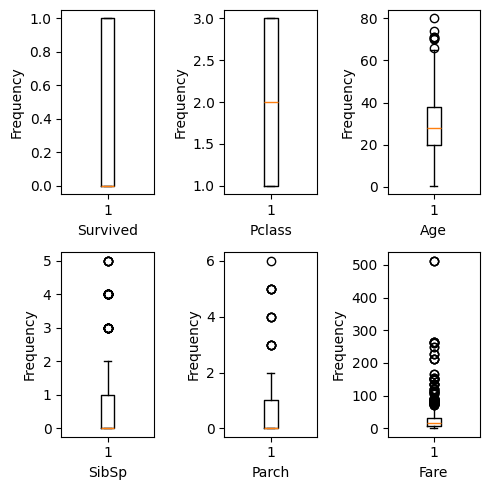

                    Fare
count         712.000000
missing         0.000000
mean           34.567251
std            52.938648
min             0.000000
25%             8.050000
50% (median)   15.645850
75%            33.000000
max           512.329200
skew            4.667009
kurtosis       31.013377


In [82]:
num_cols = df_cleaned.select_dtypes(exclude=['object']).columns

fig,axes = plt.subplots(figsize=(5,5), ncols=3, nrows=2)
axes = axes.flatten()
temp_df = df_cleaned.dropna()
for idx, columns in enumerate(num_cols):
    ax = axes[idx]
    values = temp_df[columns]
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    print(f"outliers for {columns}:", len(values[(values < lower) | (values > upper)]))
    ax.boxplot(values, whis=1.5)
    ax.set_xlabel(columns)
    ax.set_ylabel('Frequency')
    ax.set_label(columns)
plt.tight_layout()
plt.show()



def detailed_summary(series):
    return pd.Series({
        'count': series.count(),
        'missing': series.isnull().sum(),
        'mean': series.mean(),
        'std': series.std(),
        'min': series.min(),
        '25%': series.quantile(0.25),
        '50% (median)': series.median(),
        '75%': series.quantile(0.75),
        'max': series.max(),
        'skew': series.skew(),
        'kurtosis': series.kurt()
    })

print(temp_df[['Fare']].apply(detailed_summary))
del temp_df

From what it looks like we can replace the null values with the mean of the column for age, and the most common value for embarked.

In [83]:
# replacing all the null vaues in the Age and Embarked columns
df_cleaned.fillna({'Age': df_cleaned['Age'].mean(), 'Embarked': df_cleaned['Embarked'].mode()[0]}, inplace=True)

print(df_cleaned.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [84]:
df_cleaned

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.000000,1,0,7.2500,S
1,1,1,female,38.000000,1,0,71.2833,C
2,1,3,female,26.000000,0,0,7.9250,S
3,1,1,female,35.000000,1,0,53.1000,S
4,0,3,male,35.000000,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S
887,1,1,female,19.000000,0,0,30.0000,S
888,0,3,female,29.699118,1,2,23.4500,S
889,1,1,male,26.000000,0,0,30.0000,C


In [88]:
def encode_cols(df, cat_cols):
    df = df.copy() 
    for col in cat_cols:
        if df[col].nunique() > 2:
            dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
            df = pd.concat([df.drop(columns=[col]), dummies], axis=1)
        else:
            df[col] = df[col].astype('category').cat.codes
    return df

cat_cols = df_cleaned.select_dtypes(include=['object']).columns
df_encoded = encode_cols(df_cleaned, cat_cols)
df_encoded.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True


<Axes: >

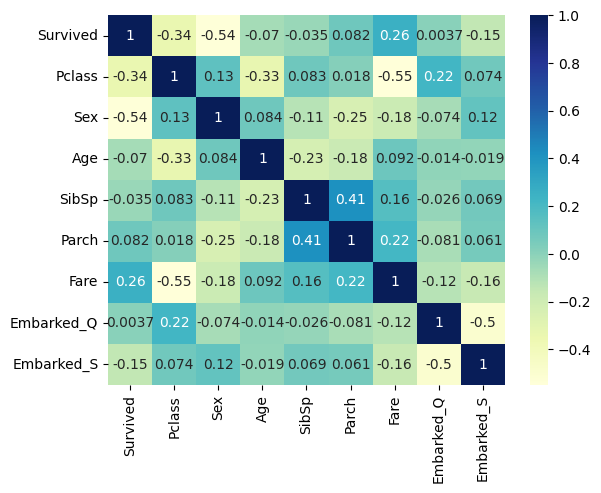

In [89]:
# correlation analysis 

sns.heatmap(df_encoded.corr(), annot=True, cmap='YlGnBu')

- Sex has a strong negative correlation (-0.54) with survival.
- Fare has a moderate positive correlation (0.26) with survival, indicating higher-paying passengers had better survival chances.
- Pclass shows a negative correlation (-0.34) with survival, meaning passengers in higher classes were more likely to survive.
- SibSp and Parch have a positive correlation (0.41) with each other.